# Step 1: Set up your Google Colab environment

 -->open google collab

 -->create a new notebook

 -->upload your csv file to the colab environment


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Supermart Grocery Sales - Retail Analytics Dataset.csv to Supermart Grocery Sales - Retail Analytics Dataset (1).csv


# Step 2: Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline


# Step 3: Load the Dataset

In [ ]:
# Load the CSV file
df = pd.read_csv('Supermart Grocery Sales - Retail Analytics Dataset.csv')

# Preview the dataset
df.head()


,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


# Step 4: Preprocessing


In [ ]:
#1. Check for nulls and duplicates
python
Copy code

df.isnull().sum()
df.duplicated().sum()

# Drop nulls and duplicates
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)


In [ ]:
#2. Convert Order Date to datetime

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Order Day'] = df['Order Date'].dt.day
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year


In [ ]:
#3. Label encode categorical features


le = LabelEncoder()
for col in ['Category', 'Sub Category', 'City', 'Region', 'State']:
    df[col] = le.fit_transform(df[col])


# Step 5: Exploratory Data Analysis (EDA)


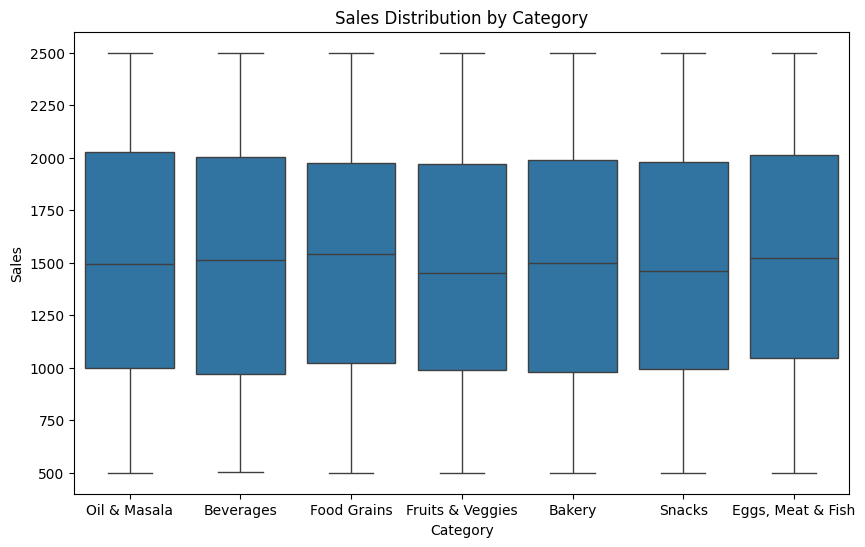

In [ ]:
#Sales by Category

plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Sales', data=df)
plt.title('Sales Distribution by Category')
plt.show()


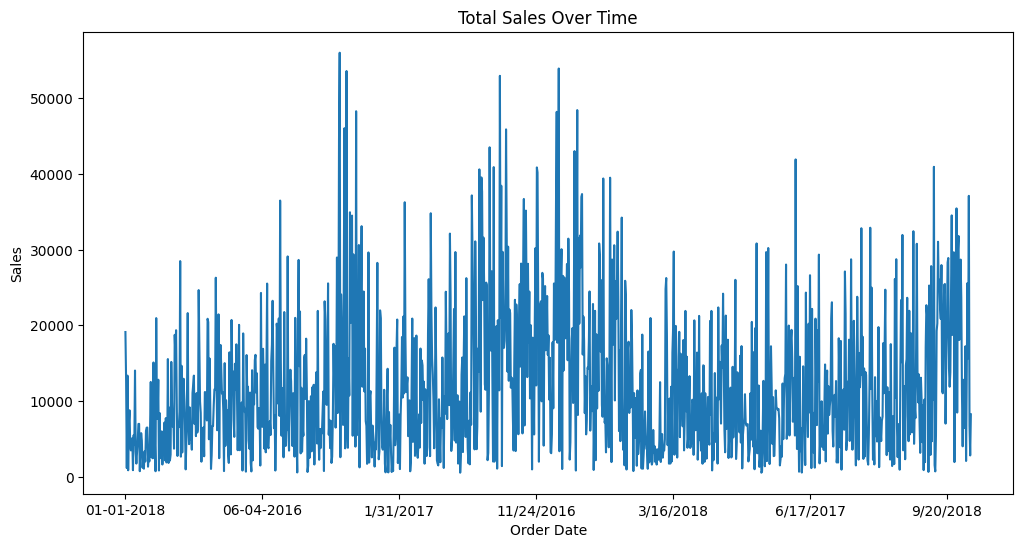

In [ ]:
#Sales Trend Over Time
df.groupby('Order Date')['Sales'].sum().plot(figsize=(12, 6))
plt.title('Total Sales Over Time')
plt.ylabel('Sales')
plt.show()


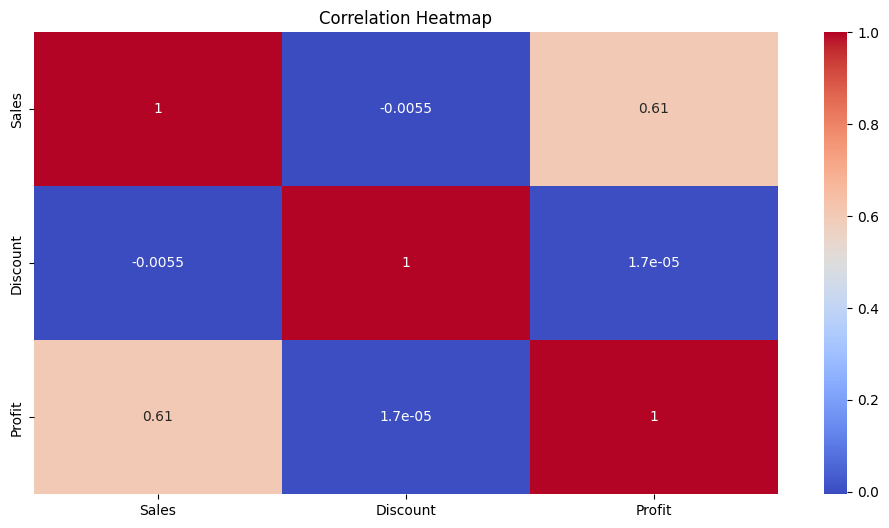

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(12, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()



# Step 6: Feature Selection and Model Building


In [ ]:
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
categorical_cols = ['Category', 'Sub Category', 'City', 'Region', 'State']
le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
features = df_encoded.drop(columns=['Order ID', 'Customer Name', 'Order Date', 'Sales'])
target = df_encoded['Sales']
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Step 7: Train and Evaluate Linear Regression Model


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")


Mean Squared Error: 212824.5973664153
R-squared: 0.3547183704729946


# Step 8: Visualize Predictions


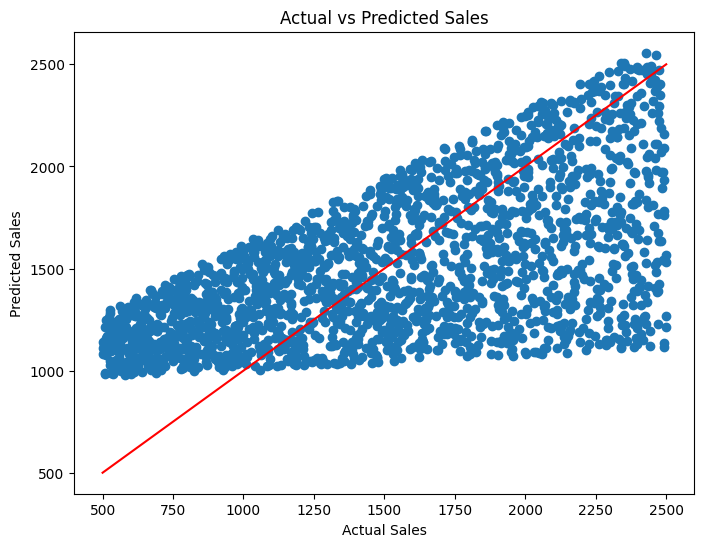

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()


# Step 9: Final predictions

In [ ]:
# Step 9: Final Predictions
y_pred = model.predict(X_test)
comparison_df = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
}).reset_index(drop=True)
print(comparison_df)


      Actual Sales  Predicted Sales
0              523      1129.534194
1             1301      1521.991662
2             1154      1148.349194
3             2045      2227.870270
4              639      1171.536674
...            ...              ...
1994          2098      2036.876452
1995          2484      1893.147222
1996          1624      1711.429945
1997           824      1182.555949
1998           624      1021.372879

[1999 rows x 2 columns]


# >>>>>>   FINAL REPORT  FILE   >>>>>>>





In [ ]:
from google.colab import files
files.download('/content/final prediction.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>